<a id="init"></a>
# Guía práctica de Machine Learning supervisado


## Objetivo del notebook

Este cuaderno no pretende ser una receta mágica. Pretende ser una **guía de pensamiento**:

- qué mirar antes de modelar,
- qué decisiones conviene tomar,
- qué errores habituales evitar,
- cómo convertir exploración y limpieza en un flujo reproducible,
- y cómo llegar a un modelo evaluado de forma honesta.


## Índice

1. [Carga de datos](#carga_datos)  
2. [Tipo de problema de Machine Learning](#reg_clas)  
3. [División train/test](#split_train_test)  
4. [Análisis del target](#target)  
5. [Comprensión de variables](#data_compr)  
6. [Reducción preliminar de features](#feat_red_prelim)  
7. [Análisis univariante](#univariante)  
8. [Análisis bivariante](#bivariante)  
9. [Eliminación de features](#del_features)  
10. [Duplicados](#duplicados)  
11. [Missings](#missings)  
12. [Anomalías y errores](#errores)  
13. [Outliers](#outliers)  
14. [Feature Engineering](#feat_engi)  
15. [Feature Reduction](#feat_reduc)  
16. [Escoger métrica](#choose_metric)  
17. [Decidir modelos](#choose_models)  
18. [Elegir hiperparámetros](#hyperparameters)  
19. [Pipelines y comparación de modelos](#pipelines)  
20. [Resultados y guardado del modelo](#results)

## Esquema mental del flujo

```text
Pregunta de negocio
      │
      ▼
Datos disponibles ──► comprensión ──► limpieza ──► feature engineering
      │                                      │
      ▼                                      ▼
Definir target                      evitar data leakage
      │                                      │
      ▼                                      ▼
Train / validation / test ──► pipelines ──► modelos ──► métricas ──► decisión
```

La idea central es sencilla: **no queremos entrenar el modelo que mejor memoriza nuestros datos; queremos entrenar el modelo que mejor generaliza a datos nuevos**.

In [2]:
# ============================================================
# 0. Setup del notebook
# ============================================================

# Si estás en un entorno limpio y te falta algún paquete, puedes descomentar:
# !pip install -U numpy pandas matplotlib seaborn scipy scikit-learn joblib

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import platform
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats

import sklearn
from sklearn import set_config

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Para que sklearn devuelva tablas pandas en algunos transformadores cuando sea posible.
# Si tu versión no lo soporta, el try evita que se rompa el notebook.
try:
    set_config(transform_output="pandas")
except Exception:
    pass

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.12
Sistema: Windows-11-10.0.26200-SP0
numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.1
scikit-learn: 1.8.0


In [3]:
# Pequeño helper para crear OneHotEncoder compatible con versiones nuevas y algo más antiguas.
# En sklearn moderno se usa sparse_output=False.
# En versiones antiguas se usaba sparse=False.

from sklearn.preprocessing import OneHotEncoder

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [4]:
# ============================================================
# 1. Creamos datasets autocontenidos
# ============================================================

from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer

def make_customer_churn_dataset(n=650, random_state=42):
    """
    Dataset sintético con sabor realista para practicar un proyecto de clasificación.

    Incluye:
    - variables numéricas,
    - variables categóricas,
    - missings,
    - duplicados,
    - outliers,
    - errores imposibles,
    - target binario algo desbalanceado.
    """
    rng = np.random.default_rng(random_state)

    edad = np.round(rng.normal(42, 12, n)).clip(18, 80).astype(int)
    antiguedad_meses = np.round(rng.exponential(30, n)).clip(0, 180).astype(int)
    ingresos_mensuales = np.exp(rng.normal(np.log(2200), 0.45, n)).clip(650, 8500)
    gasto_mensual = (ingresos_mensuales * rng.uniform(0.04, 0.32, n) + rng.normal(0, 60, n)).clip(20, 2800)
    num_reclamaciones = rng.poisson(0.65, n).clip(0, 8)
    visitas_web_mes = rng.poisson(5, n).clip(0, 30)

    canal_entrada = rng.choice(["web", "tienda", "call_center"], size=n, p=[0.52, 0.30, 0.18])
    segmento = rng.choice(["basic", "plus", "premium"], size=n, p=[0.56, 0.30, 0.14])
    provincia = rng.choice(
        ["Valencia", "Madrid", "Barcelona", "Alicante", "Sevilla", "Bilbao", "Zaragoza", "Málaga"],
        size=n,
        p=[0.26, 0.22, 0.17, 0.11, 0.08, 0.06, 0.05, 0.05],
    )
    usa_app = rng.choice(["sí", "no"], size=n, p=[0.68, 0.32])

    # Probabilidad latente de churn: inventada, pero coherente.
    gasto_relativo = gasto_mensual / ingresos_mensuales
    logit = (
        -2.10
        + 0.75 * (num_reclamaciones >= 2)
        + 0.55 * (antiguedad_meses < 6)
        + 0.45 * (usa_app == "no")
        + 0.45 * (canal_entrada == "call_center")
        + 0.35 * (segmento == "basic")
        + 0.25 * (gasto_relativo > 0.22)
        - 0.35 * (segmento == "premium")
        - 0.25 * (edad > 50)
    )
    prob_churn = 1 / (1 + np.exp(-logit))
    churn = rng.binomial(1, prob_churn)

    df = pd.DataFrame({
        "id_cliente": [f"C{str(i).zfill(5)}" for i in range(n)],
        "edad": edad,
        "antiguedad_meses": antiguedad_meses,
        "ingresos_mensuales": np.round(ingresos_mensuales, 2),
        "gasto_mensual": np.round(gasto_mensual, 2),
        "num_reclamaciones": num_reclamaciones,
        "visitas_web_mes": visitas_web_mes,
        "canal_entrada": canal_entrada,
        "segmento": segmento,
        "provincia": provincia,
        "usa_app": usa_app,
        "churn": churn,
    })

    # Missings: simulamos problemas típicos de captura/integración de datos.
    for col, p in {
        "ingresos_mensuales": 0.06,
        "gasto_mensual": 0.035,
        "canal_entrada": 0.025,
        "segmento": 0.018,
    }.items():
        idx = rng.choice(df.index, size=int(n * p), replace=False)
        df.loc[idx, col] = np.nan

    # Outliers y errores artificiales.
    out_idx = rng.choice(df.index, size=6, replace=False)
    df.loc[out_idx[:3], "ingresos_mensuales"] = [25_000, 32_000, 41_000]
    df.loc[out_idx[3:], "gasto_mensual"] = [7_500, 8_200, 9_100]

    error_idx = rng.choice(df.index, size=5, replace=False)
    df.loc[error_idx[0], "edad"] = -4
    df.loc[error_idx[1], "edad"] = 130
    df.loc[error_idx[2], "antiguedad_meses"] = -10
    df.loc[error_idx[3], "canal_entrada"] = "desconocido??"
    df.loc[error_idx[4], "usa_app"] = "quizá"

    # Duplicados exactos.
    duplicated_rows = df.sample(8, random_state=random_state)
    df = pd.concat([df, duplicated_rows], ignore_index=True)

    return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

clientes_df = make_customer_churn_dataset()

# Datasets clásicos integrados en sklearn. No requieren ficheros externos del profesor.
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df["target_name"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

diabetes = load_diabetes(as_frame=True)
diabetes_df = diabetes.frame.copy()

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()
cancer_df["target_name"] = cancer_df["target"].map(dict(enumerate(cancer.target_names)))

print("clientes_df:", clientes_df.shape)
print("iris_df:", iris_df.shape)
print("diabetes_df:", diabetes_df.shape)
print("cancer_df:", cancer_df.shape)

clientes_df: (658, 12)
iris_df: (150, 6)
diabetes_df: (442, 11)
cancer_df: (569, 32)


In [5]:
clientes_df.head()

,id_cliente,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,churn
0,C00592,64,48,"2,676.240",194.230,2,3,tienda,basic,Barcelona,sí,0
1,C00310,56,4,"4,500.380",554.080,0,7,call_center,basic,Valencia,sí,0
2,C00291,44,47,"1,994.710",311.520,2,2,call_center,basic,Barcelona,sí,0
3,C00063,49,0,"3,819.700",696.430,1,4,tienda,basic,Madrid,sí,1
4,C00350,46,2,"2,201.980",231.610,0,1,web,plus,Alicante,no,0


<a id="carga_datos"></a>
[Volver al índice](#init)

# 1. Carga de datos

En un proyecto real, los datos pueden venir de muchas fuentes:

| Fuente | Ejemplo | Función típica |
|---|---|---|
| CSV / TSV / TXT | `datos.csv`, `datos.tsv` | `pd.read_csv()` |
| Excel | `ventas.xlsx` | `pd.read_excel()` |
| JSON | API, logs, NoSQL | `pd.read_json()` |
| SQL | SQLite, PostgreSQL, BigQuery... | `pd.read_sql()` |
| Web | tablas HTML | `pd.read_html()` |
| Librerías | datasets de `sklearn`, `statsmodels`, etc. | loaders específicos |

En clase conviene distinguir entre dos ideas:

1. **El notebook debe ser reproducible**: si otra persona lo ejecuta, debe llegar a un resultado parecido.
2. **Los datos deben estar accesibles**: pueden venir incluidos, generarse o descargarse desde una URL estable, pero no deberían depender de “te paso también esta carpeta con imágenes y CSVs”.

En esta versión del cuaderno todo se genera o se carga desde datasets integrados.

In [6]:
# Ejemplo de lectura desde una URL pública.
# Lo dejamos comentado porque este notebook NO depende de internet.

# url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
# penguins_df = pd.read_csv(url)
# penguins_df.head()

## Problemas típicos al cargar datos

Antes de modelar, conviene revisar:

- **Separador**: coma, punto y coma, tabulador...
- **Decimal**: punto o coma decimal.
- **Encoding**: UTF-8, latin-1, cp1252...
- **Cabeceras**: si la primera fila contiene nombres de columnas o datos reales.
- **Múltiples tablas**: a veces tenemos que cruzar varias fuentes.
- **Train/test separados**: habitual en Kaggle y competiciones.
- **Definición del target**: no siempre está claro qué columna queremos predecir.

Ejemplo típico:

```python
pd.read_csv("datos.csv", sep=";", decimal=",", encoding="utf-8")
```

In [7]:
# Primer vistazo general a nuestros datos sintéticos
clientes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_cliente          658 non-null    str    
 1   edad                658 non-null    int64  
 2   antiguedad_meses    658 non-null    int64  
 3   ingresos_mensuales  619 non-null    float64
 4   gasto_mensual       636 non-null    float64
 5   num_reclamaciones   658 non-null    int64  
 6   visitas_web_mes     658 non-null    int64  
 7   canal_entrada       641 non-null    str    
 8   segmento            647 non-null    str    
 9   provincia           658 non-null    str    
 10  usa_app             658 non-null    str    
 11  churn               658 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 61.8 KB


In [8]:
# Dimensiones y primeras columnas
print("Filas:", clientes_df.shape[0])
print("Columnas:", clientes_df.shape[1])
clientes_df.head(3)

Filas: 658
Columnas: 12


,id_cliente,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,churn
0,C00592,64,48,"2,676.240",194.230,2,3,tienda,basic,Barcelona,sí,0
1,C00310,56,4,"4,500.380",554.080,0,7,call_center,basic,Valencia,sí,0
2,C00291,44,47,"1,994.710",311.520,2,2,call_center,basic,Barcelona,sí,0


## Joins: cuando los datos vienen en varias tablas

Aunque este notebook no depende de archivos externos, podemos simular dos tablas y unirlas.

Tipos frecuentes de unión:

| Tipo de join | Qué conserva |
|---|---|
| `inner` | Solo claves presentes en ambas tablas |
| `left` | Todas las filas de la izquierda |
| `right` | Todas las filas de la derecha |
| `outer` | Todas las claves de ambas tablas |

La pregunta importante no es solo “qué join uso”, sino: **¿qué significa perder o duplicar filas después del join?**

In [9]:
clientes_base = clientes_df[["id_cliente", "edad", "provincia", "churn"]].drop_duplicates("id_cliente")
contratos = clientes_df[["id_cliente", "antiguedad_meses", "segmento", "usa_app"]].drop_duplicates("id_cliente")

clientes_join = clientes_base.merge(contratos, on="id_cliente", how="left")
clientes_join.head()

,id_cliente,edad,provincia,churn,antiguedad_meses,segmento,usa_app
0,C00592,64,Barcelona,0,48,basic,sí
1,C00310,56,Valencia,0,4,basic,sí
2,C00291,44,Barcelona,0,47,basic,sí
3,C00063,49,Madrid,1,0,basic,sí
4,C00350,46,Alicante,0,2,plus,no


In [10]:
print("Filas base:", len(clientes_base))
print("Filas contratos:", len(contratos))
print("Filas tras left join:", len(clientes_join))

Filas base: 650
Filas contratos: 650
Filas tras left join: 650


<a id="reg_clas"></a>
[Volver al índice](#init)

# 2. Tipo de problema de Machine Learning

Este notebook se centra en **aprendizaje supervisado**:

| Tipo | Target | Ejemplo |
|---|---|---|
| Clasificación binaria | clase con 2 valores | churn sí/no, fraude sí/no |
| Clasificación multiclase | clase con más de 2 valores | especie de flor, tipo de cliente |
| Regresión | valor continuo | precio, demanda, consumo, temperatura |

También existen otros escenarios:

- **No supervisado**: clustering, reducción de dimensionalidad, detección de anomalías.
- **Series temporales**: predicción donde el orden temporal importa.
- **Recomendadores**: predicción de preferencias o rankings.
- **NLP / visión**: texto, imágenes, audio, vídeo.

En este notebook trabajaremos principalmente con:

- `clientes_df`: clasificación binaria (`churn`).
- `iris_df`: clasificación multiclase.
- `diabetes_df`: regresión.

In [11]:
print("Target de clientes_df:")
print(clientes_df["churn"].value_counts(dropna=False))

print("\nTarget de iris_df:")
print(iris_df["target_name"].value_counts())

print("\nTarget de diabetes_df:")
display(diabetes_df["target"].describe())

Target de clientes_df:
churn
0    536
1    122
Name: count, dtype: int64

Target de iris_df:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Target de diabetes_df:


count   442.000
mean    152.133
std      77.093
min      25.000
25%      87.000
50%     140.500
75%     211.500
max     346.000
Name: target, dtype: float64

<a id="split_train_test"></a>
[Volver al índice](#init)

# 3. División train/test

Una de las decisiones más importantes del proyecto es separar una parte de los datos para evaluar al final.

## Regla de oro

> Todo lo que aprenda parámetros a partir de los datos debe ajustarse con `train`, no con `test`.

Esto afecta a:

- imputadores de missings,
- escaladores,
- encoders,
- selección de variables,
- PCA,
- oversampling/undersampling,
- ajuste de hiperparámetros,
- cualquier transformación que “mire” los datos.

El conjunto de test representa datos futuros. Si contaminamos test, nuestras métricas serán demasiado optimistas.

In [12]:
from sklearn.model_selection import train_test_split

X = clientes_df.drop(columns=["churn"])
y = clientes_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,  # importante en clasificación si hay desbalanceo
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Distribución train:")
print(y_train.value_counts(normalize=True).round(3))
print("Distribución test:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (526, 11)
X_test: (132, 11)
Distribución train:
churn
0   0.814
1   0.186
Name: proportion, dtype: float64
Distribución test:
churn
0   0.818
1   0.182
Name: proportion, dtype: float64


## Ejemplo de fuga de información con escalado

Incorrecto:

```python
scaler.fit(X_total)
```

Correcto:

```python
scaler.fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)
```

Mejor todavía: meterlo dentro de un `Pipeline`, para que `scikit-learn` se encargue de aplicar cada paso en el momento correcto.

In [13]:
from sklearn.preprocessing import StandardScaler

# Ejemplo con variables numéricas limpias para ilustrar la idea.
num_cols_demo = ["edad", "antiguedad_meses", "num_reclamaciones", "visitas_web_mes"]

X_train_num = X_train[num_cols_demo].copy()
X_test_num = X_test[num_cols_demo].copy()

scaler = StandardScaler()
scaler.fit(X_train_num)  # solo train

X_train_scaled = scaler.transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

print("Medias aprendidas en train:")
print(pd.Series(scaler.mean_, index=num_cols_demo))

Medias aprendidas en train:
edad                41.441
antiguedad_meses    28.954
num_reclamaciones    0.652
visitas_web_mes      4.846
dtype: float64


<a id="target"></a>
[Volver al índice](#init)

# 4. Análisis del target

Antes de mirar features, conviene mirar el target.

| Tipo de problema | Qué mirar | Riesgo |
|---|---|---|
| Clasificación | balance de clases | accuracy engañosa |
| Regresión | distribución y rango | errores dominados por valores extremos |

## Clasificación desbalanceada

Si el 95% de los casos son “no churn”, un modelo que prediga siempre “no churn” tendrá 95% de accuracy y será inútil para detectar clientes que se van.

Por eso conviene mirar otras métricas: `precision`, `recall`, `f1`, `balanced_accuracy`, curva ROC o precision-recall.

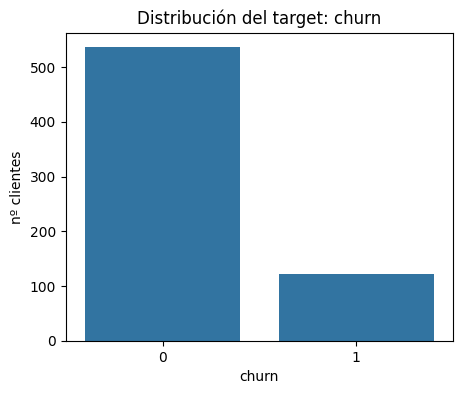

,proporción
churn,
0,0.815
1,0.185


In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=clientes_df, x="churn", ax=ax, color="C0")
ax.set_title("Distribución del target: churn")
ax.set_xlabel("churn")
ax.set_ylabel("nº clientes")
plt.show()

clientes_df["churn"].value_counts(normalize=True).rename("proporción").to_frame()

## Rebalanceo: demostración sin depender de `imblearn`

`imbalanced-learn` es una librería muy útil, pero aquí evitamos depender de paquetes adicionales. Para enseñar la idea, podemos hacer un oversampling simple con `sklearn.utils.resample`.

Puntos importantes:

- No se evalúa sobre el dataset rebalanceado.
- No se rebalancea antes de hacer train/test split.
- En un proyecto serio, el rebalanceo debe estar dentro del flujo de validación cruzada.

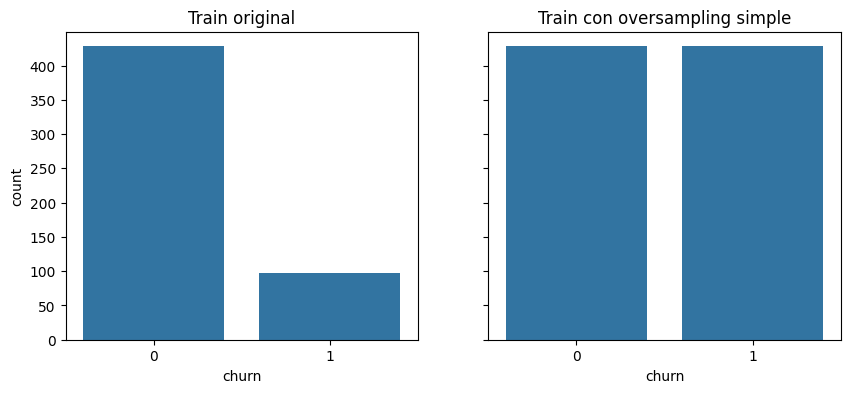

In [15]:
from sklearn.utils import resample

train_tmp = X_train.copy()
train_tmp["churn"] = y_train.values

majority = train_tmp[train_tmp["churn"] == 0]
minority = train_tmp[train_tmp["churn"] == 1]

minority_up = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=RANDOM_STATE,
)

train_balanced = pd.concat([majority, minority_up]).sample(frac=1, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
sns.countplot(data=train_tmp, x="churn", ax=axes[0], color="C0")
axes[0].set_title("Train original")
sns.countplot(data=train_balanced, x="churn", ax=axes[1], color="C0")
axes[1].set_title("Train con oversampling simple")
plt.show()

## Target de regresión

En regresión no hay clases, pero sí nos importa la distribución:

- ¿hay asimetría?
- ¿hay valores extremos?
- ¿tiene sentido aplicar logaritmo?
- ¿hay ceros o negativos?
- ¿qué significa un error de 10 unidades en este dominio?

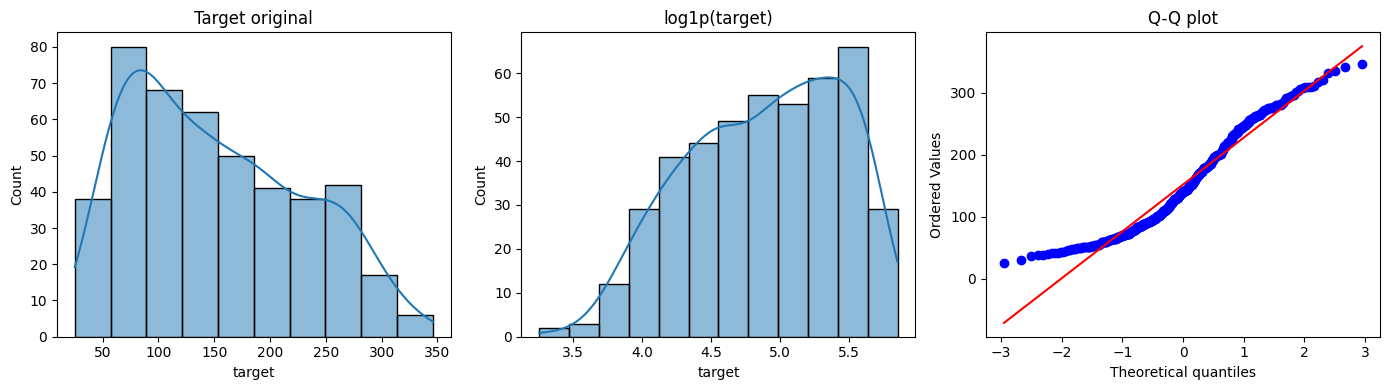

In [16]:
y_reg = diabetes_df["target"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(y_reg, kde=True, ax=axes[0], color="C0")
axes[0].set_title("Target original")

sns.histplot(np.log1p(y_reg), kde=True, ax=axes[1], color="C0")
axes[1].set_title("log1p(target)")

stats.probplot(y_reg, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

**Nota sobre transformaciones del target**  
Si entrenamos con un target transformado, luego debemos aplicar la transformación inversa a las predicciones. En `scikit-learn`, esto puede hacerse de forma elegante con `TransformedTargetRegressor`.

<a id="data_compr"></a>
[Volver al índice](#init)

# 5. Comprensión de variables

Antes de programar transformaciones a lo loco, conviene entender las variables.

Preguntas útiles:

- ¿Qué significa esta columna?
- ¿Es numérica, categórica, ordinal, binaria, identificador, fecha?
- ¿Tiene sentido usarla para predecir o es una fuga de información?
- ¿Tiene missings?
- ¿Tiene demasiada cardinalidad?
- ¿Contiene errores imposibles?
- ¿Puede estar medida después del evento que queremos predecir?

Una tabla de comprensión de variables es una herramienta muy potente para clase y para proyectos reales.

In [17]:
def data_report(df: pd.DataFrame) -> pd.DataFrame:
    """Reporte compacto de columnas."""
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": df.isna().mean().mul(100).round(2),
        "n_unique": df.nunique(dropna=True),
        "pct_unique": df.nunique(dropna=True).div(len(df)).mul(100).round(2),
    })
    examples = []
    for col in df.columns:
        vals = df[col].dropna().unique()[:4]
        examples.append(list(vals))
    report["examples"] = examples
    return report.sort_values(["pct_missing", "pct_unique"], ascending=False)

data_report(clientes_df)

,dtype,n_missing,pct_missing,n_unique,pct_unique,examples
ingresos_mensuales,float64,39,5.930,606,92.100,"[2676.24, 4500.38, 1994.71, 3819.7]"
gasto_mensual,float64,22,3.340,619,94.070,"[194.23, 554.08, 311.52, 696.43]"
canal_entrada,str,17,2.580,4,0.610,"[tienda, call_center, web, desconocido??]"
segmento,str,11,1.670,3,0.460,"[basic, plus, premium]"
id_cliente,str,0,0.000,650,98.780,"[C00592, C00310, C00291, C00063]"
antiguedad_meses,int64,0,0.000,109,16.570,"[48, 4, 47, 0]"
edad,int64,0,0.000,58,8.810,"[64, 56, 44, 49]"
visitas_web_mes,int64,0,0.000,15,2.280,"[3, 7, 2, 4]"
provincia,str,0,0.000,8,1.220,"[Barcelona, Valencia, Madrid, Alicante]"
num_reclamaciones,int64,0,0.000,6,0.910,"[2, 0, 1, 3]"


In [18]:
clientes_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,658,650,C00072,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,658.000,NaN,NaN,NaN,41.725,12.165,-4.000,34.000,41.500,49.000,130.000
antiguedad_meses,658.000,NaN,NaN,NaN,29.381,29.574,-10.000,9.000,20.000,41.000,180.000
ingresos_mensuales,619.000,NaN,NaN,NaN,"2,454.354","2,417.467",650.000,"1,547.505","2,098.510","2,834.070","41,000.000"
gasto_mensual,636.000,NaN,NaN,NaN,462.357,694.601,20.000,200.833,358.845,568.418,"9,100.000"
num_reclamaciones,658.000,NaN,NaN,NaN,0.653,0.834,0.000,0.000,0.000,1.000,5.000
visitas_web_mes,658.000,NaN,NaN,NaN,4.916,2.272,0.000,3.000,5.000,6.000,14.000
canal_entrada,641,4,web,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segmento,647,3,basic,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,658,8,Valencia,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clasificación rápida de columnas

No todo lo que parece número debe tratarse como variable numérica. Por ejemplo:

- `id_cliente` parece texto, pero realmente es un identificador.
- `churn` es numérico, pero es target binario.
- `num_reclamaciones` es numérica discreta.
- `segmento` es categórica ordinal o semiordinal, dependiendo del dominio.

El criterio no es solo técnico. Es semántico.

In [19]:
def classify_columns(df, target=None, id_like_threshold=0.95):
    rows = []
    for col in df.columns:
        if col == target:
            kind = "target"
        elif df[col].nunique(dropna=True) / len(df) > id_like_threshold:
            kind = "posible identificador / alta cardinalidad"
        elif pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique(dropna=True) <= 12:
                kind = "numérica discreta / binaria"
            else:
                kind = "numérica continua"
        else:
            kind = "categórica"
        rows.append({"variable": col, "tipo_sugerido": kind, "n_unique": df[col].nunique(dropna=True)})
    return pd.DataFrame(rows)

classify_columns(clientes_df, target="churn")

,variable,tipo_sugerido,n_unique
0,id_cliente,posible identificador / alta cardinalidad,650
1,edad,numérica continua,58
2,antiguedad_meses,numérica continua,109
3,ingresos_mensuales,numérica continua,606
4,gasto_mensual,numérica continua,619
5,num_reclamaciones,numérica discreta / binaria,6
6,visitas_web_mes,numérica continua,15
7,canal_entrada,categórica,4
8,segmento,categórica,3
9,provincia,categórica,8


<a id="feat_red_prelim"></a>
[Volver al índice](#init)

# 6. Reducción preliminar de features

Antes de entrenar modelos, hay columnas candidatas a eliminar o revisar:

- identificadores (`id_cliente`),
- columnas con demasiados missings,
- columnas constantes o casi constantes,
- columnas con cardinalidad extrema,
- columnas duplicadas,
- columnas que contienen información futura o fuga del target.

Esta fase no debe ser automática al 100%. El código puede sugerir, pero la decisión final requiere criterio.

In [20]:
def preliminary_feature_audit(df, target=None, missing_threshold=40, cardinality_threshold=90):
    report = data_report(df)
    report["drop_candidate"] = False
    report["reason"] = ""

    for col in report.index:
        reasons = []
        if col == target:
            reasons.append("target: no eliminar, separar")
        if report.loc[col, "pct_missing"] > missing_threshold:
            reasons.append(f"muchos missings > {missing_threshold}%")
        if report.loc[col, "pct_unique"] > cardinality_threshold and col != target:
            reasons.append(f"alta cardinalidad > {cardinality_threshold}%")
        if df[col].nunique(dropna=False) <= 1:
            reasons.append("constante")

        if reasons:
            report.loc[col, "drop_candidate"] = col != target
            report.loc[col, "reason"] = "; ".join(reasons)

    return report

preliminary_feature_audit(clientes_df, target="churn")

,dtype,n_missing,pct_missing,n_unique,pct_unique,examples,drop_candidate,reason
ingresos_mensuales,float64,39,5.930,606,92.100,"[2676.24, 4500.38, 1994.71, 3819.7]",True,alta cardinalidad > 90%
gasto_mensual,float64,22,3.340,619,94.070,"[194.23, 554.08, 311.52, 696.43]",True,alta cardinalidad > 90%
canal_entrada,str,17,2.580,4,0.610,"[tienda, call_center, web, desconocido??]",False,
segmento,str,11,1.670,3,0.460,"[basic, plus, premium]",False,
id_cliente,str,0,0.000,650,98.780,"[C00592, C00310, C00291, C00063]",True,alta cardinalidad > 90%
antiguedad_meses,int64,0,0.000,109,16.570,"[48, 4, 47, 0]",False,
edad,int64,0,0.000,58,8.810,"[64, 56, 44, 49]",False,
visitas_web_mes,int64,0,0.000,15,2.280,"[3, 7, 2, 4]",False,
provincia,str,0,0.000,8,1.220,"[Barcelona, Valencia, Madrid, Alicante]",False,
num_reclamaciones,int64,0,0.000,6,0.910,"[2, 0, 1, 3]",False,


## Correlación lineal

La correlación ayuda, pero no lo explica todo.

- Mide relaciones lineales.
- No detecta bien relaciones no lineales.
- No implica causalidad.
- Puede ser engañosa si hay outliers.
- No aplica directamente a variables categóricas sin codificar.

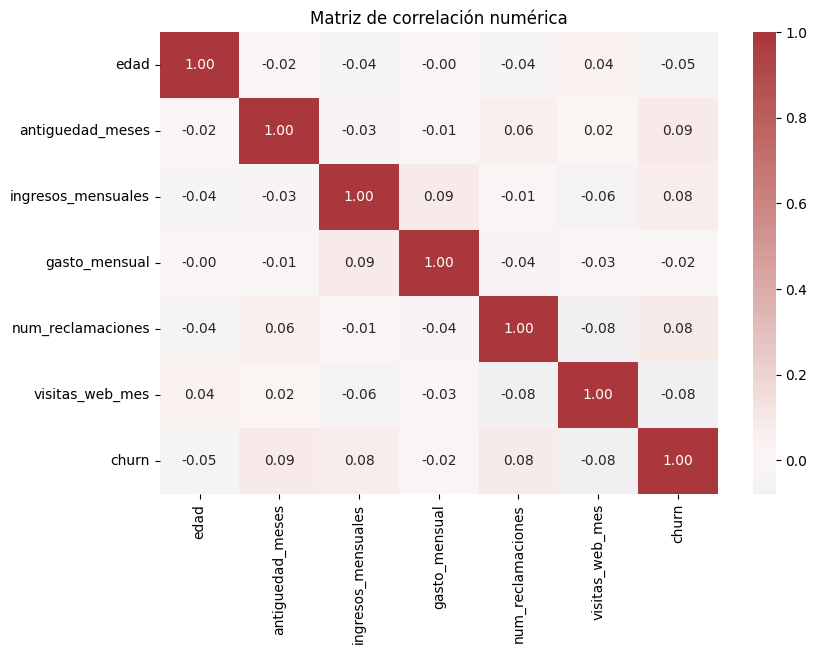

In [21]:
num_cols = clientes_df.select_dtypes(include="number").columns
corr = clientes_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Matriz de correlación numérica")
plt.show()

## Feature importance preliminar

Un modelo de árboles puede dar una primera señal de variables relevantes. Pero cuidado:

- la importancia puede estar sesgada hacia variables con más posibles cortes,
- variables correlacionadas se reparten importancia,
- no sustituye el análisis de negocio,
- debe calcularse dentro de un flujo correcto de train/test.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Versión limpia mínima para entrenar una importancia preliminar.
def basic_error_cleaning(df):
    df = df.copy()
    df.loc[~df["edad"].between(18, 90), "edad"] = np.nan
    df.loc[df["antiguedad_meses"] < 0, "antiguedad_meses"] = np.nan
    df.loc[~df["canal_entrada"].isin(["web", "tienda", "call_center"]), "canal_entrada"] = np.nan
    df.loc[~df["usa_app"].isin(["sí", "no"]), "usa_app"] = np.nan
    df = df.drop_duplicates()
    return df

clientes_clean = basic_error_cleaning(clientes_df)

X_feat = clientes_clean.drop(columns=["churn", "id_cliente"])
y_feat = clientes_clean["churn"]

numeric_features = X_feat.select_dtypes(include="number").columns.tolist()
categorical_features = X_feat.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

rf_importance_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, class_weight="balanced")),
])

rf_importance_pipe.fit(X_feat, y_feat)

feature_names = rf_importance_pipe.named_steps["preprocess"].get_feature_names_out()
importances = rf_importance_pipe.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

importance_df

,feature,importance
3,num__gasto_mensual,0.149
0,num__edad,0.145
2,num__ingresos_mensuales,0.143
1,num__antiguedad_meses,0.142
5,num__visitas_web_mes,0.101
4,num__num_reclamaciones,0.049
9,cat__segmento_basic,0.024
18,cat__provincia_Valencia,0.023
8,cat__canal_entrada_web,0.022
20,cat__usa_app_no,0.020


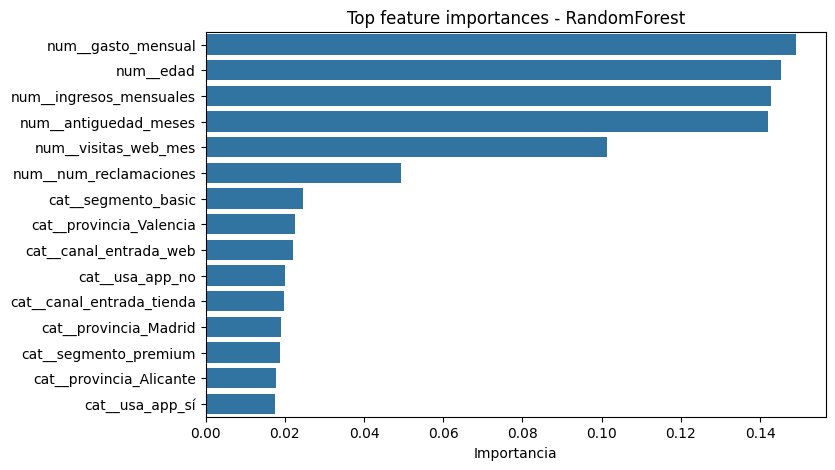

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, y="feature", x="importance", color="C0")
plt.title("Top feature importances - RandomForest")
plt.xlabel("Importancia")
plt.ylabel("")
plt.show()

<a id="univariante"></a>
[Volver al índice](#init)

# 7. Análisis univariante

El análisis univariante mira cada variable por separado.

Sirve para detectar:

- distribuciones raras,
- asimetrías,
- categorías con muy pocos casos,
- missings,
- valores imposibles,
- outliers,
- escalas muy distintas.

No responde todavía a “qué relación tiene con el target”, pero prepara el terreno.

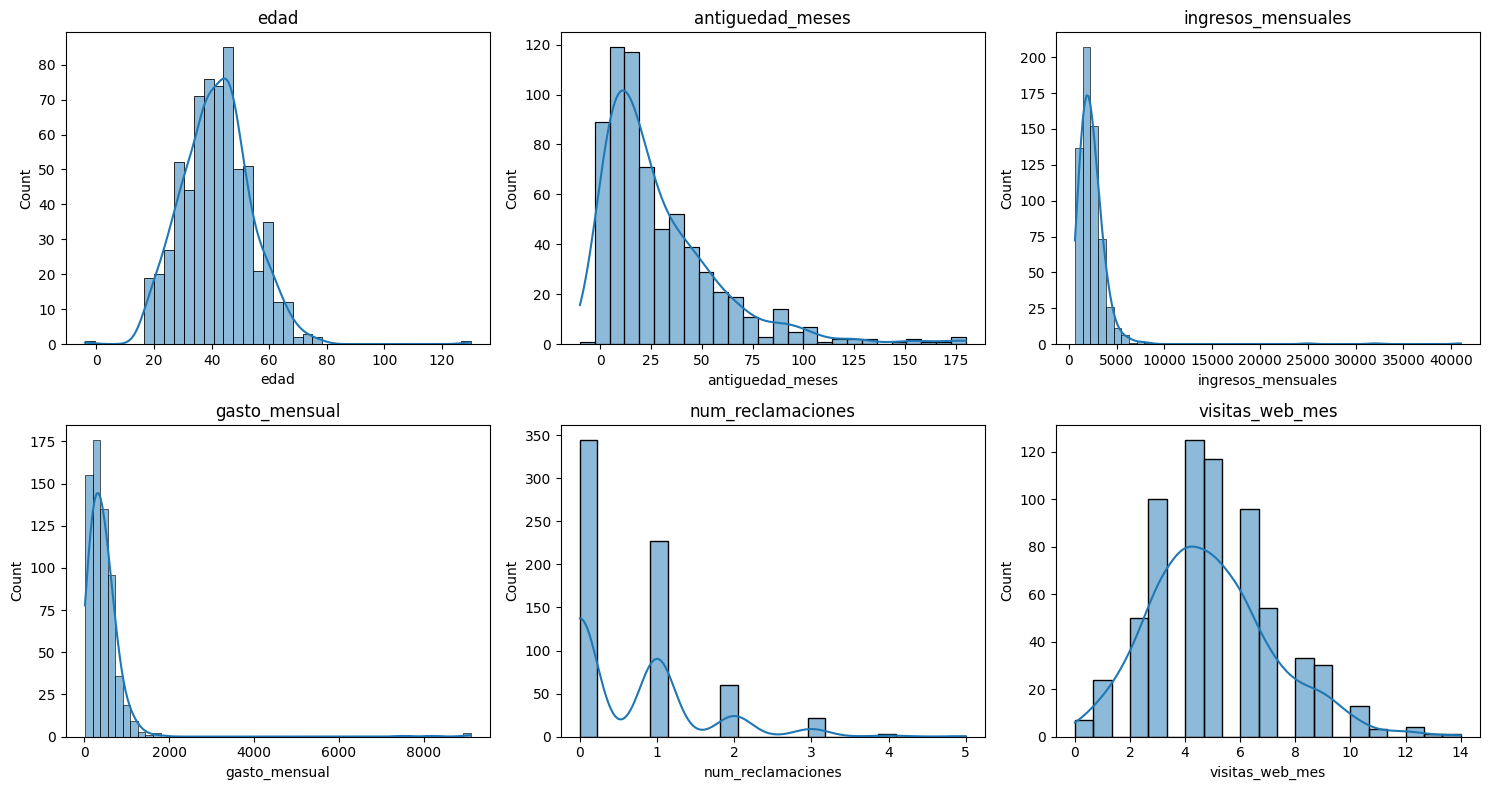

In [24]:
# Variables numéricas: histogramas
num_to_plot = ["edad", "antiguedad_meses", "ingresos_mensuales", "gasto_mensual", "num_reclamaciones", "visitas_web_mes"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_to_plot):
    sns.histplot(clientes_df[col], kde=True, ax=ax, color="C0")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [27]:
clientes_df

,id_cliente,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,churn
0,C00592,64,48,"2,676.240",194.230,2,3,tienda,basic,Barcelona,sí,0
1,C00310,56,4,"4,500.380",554.080,0,7,call_center,basic,Valencia,sí,0
2,C00291,44,47,"1,994.710",311.520,2,2,call_center,basic,Barcelona,sí,0
3,C00063,49,0,"3,819.700",696.430,1,4,tienda,basic,Madrid,sí,1
4,C00350,46,2,"2,201.980",231.610,0,1,web,plus,Alicante,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...
653,C00071,28,5,"2,559.570",217.950,0,4,call_center,basic,Alicante,sí,0
654,C00106,31,18,"4,132.950",283.790,5,5,call_center,plus,Zaragoza,no,0
655,C00270,-4,22,"3,362.560",NaN,0,4,call_center,basic,Barcelona,no,0
656,C00435,35,12,"1,637.370",200.750,0,6,web,basic,Sevilla,no,1


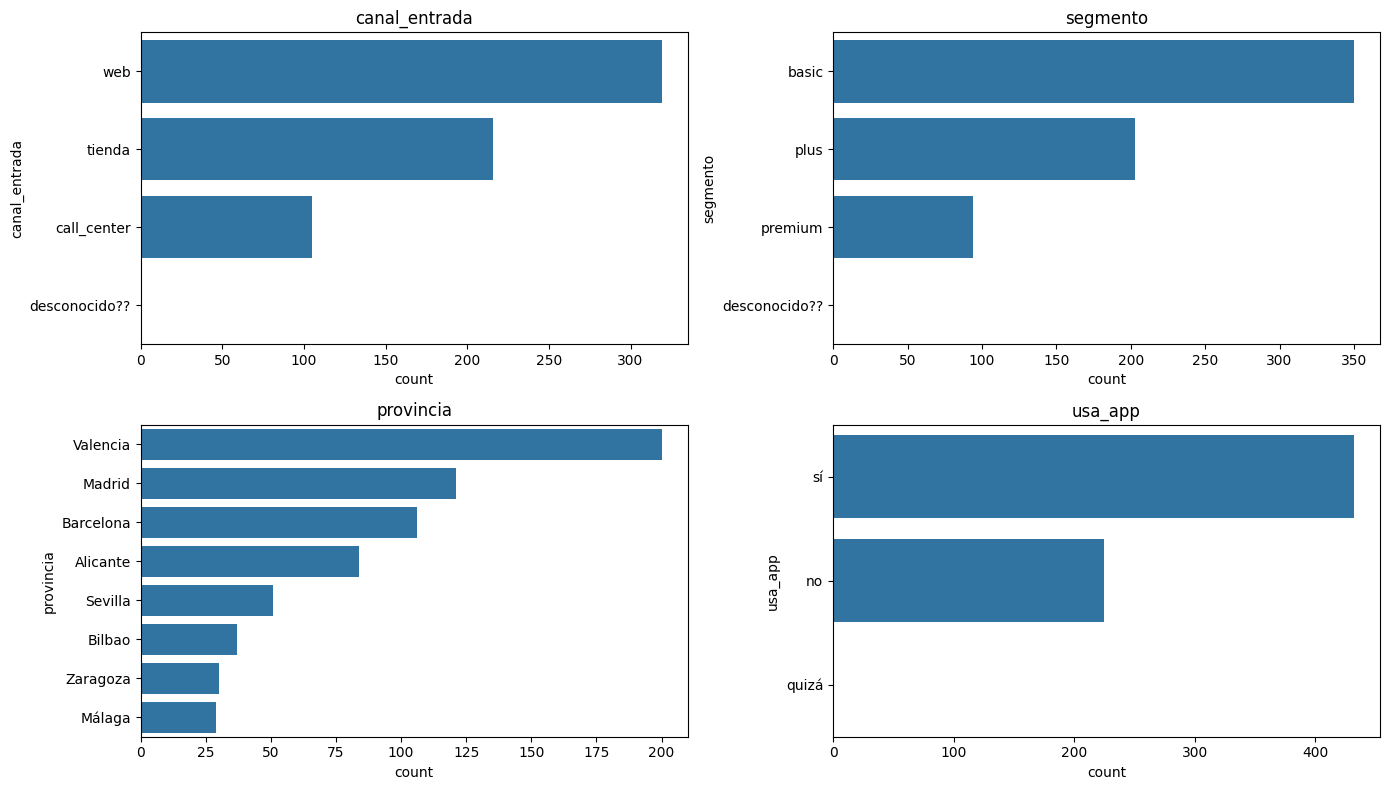

In [44]:
# Variables categóricas: frecuencias
cat_to_plot = ["canal_entrada", "segmento", "provincia", "usa_app"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cat_to_plot):
    order = clientes_df[col].fillna("desconocido??").value_counts(dropna=False).index
    sns.countplot(data=clientes_df, y=col, order=order, ax=ax, color="C0")
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Análisis rápido de una columna

Es útil crear pequeñas funciones reutilizables. La idea no es ocultar el análisis, sino ahorrar tiempo en comprobaciones repetitivas.

Variable: ingresos_mensuales
dtype: float64
missings: 39 (5.93%)
n_unique: 606

Top valores:


,count
ingresos_mensuales,
NaN,39
650.000,5
"1,456.940",2
"4,277.140",2
"1,029.580",2
"2,945.370",2
"1,916.500",2
"3,030.860",2
"2,423.820",2


,count,mean,std,min,25%,50%,75%,max
ingresos_mensuales,619.000,"2,454.354","2,417.467",650.000,"1,547.505","2,098.510","2,834.070","41,000.000"


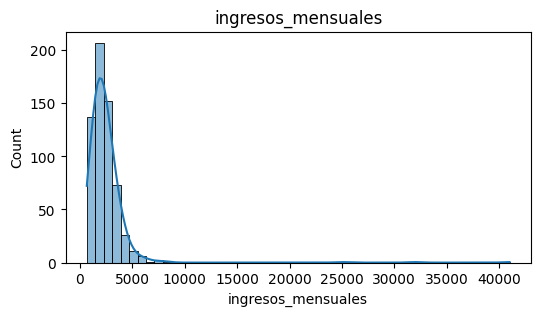

In [ ]:
def describe_column(df, col):
    print(f"Variable: {col}")
    print(f"dtype: {df[col].dtype}")
    print(f"missings: {df[col].isna().sum()} ({df[col].isna().mean()*100:.2f}%)")
    print(f"n_unique: {df[col].nunique(dropna=True)}")
    print("\nTop valores:")
    display(df[col].value_counts(dropna=False).head(10).to_frame("count"))
    
    if pd.api.types.is_numeric_dtype(df[col]):
        display(df[col].describe().to_frame().T)
        plt.figure(figsize=(6, 3))
        sns.histplot(df[col], kde=True, color="C0")
        plt.title(col)
        plt.show()

describe_column(clientes_df, "ingresos_mensuales")

<a id="bivariante"></a>
[Volver al índice](#init)

# 8. Análisis bivariante

El análisis bivariante estudia relaciones entre dos variables.

Combinaciones frecuentes:

| Variable A | Variable B | Gráficas útiles |
|---|---|---|
| numérica | numérica | scatter, heatmap, correlación |
| numérica | categórica | boxplot, violinplot, histogramas por grupo |
| categórica | categórica | tabla cruzada, barras apiladas |
| feature | target | depende de clasificación/regresión |

En clase, esta sección es muy buena para conectar visualización con hipótesis.

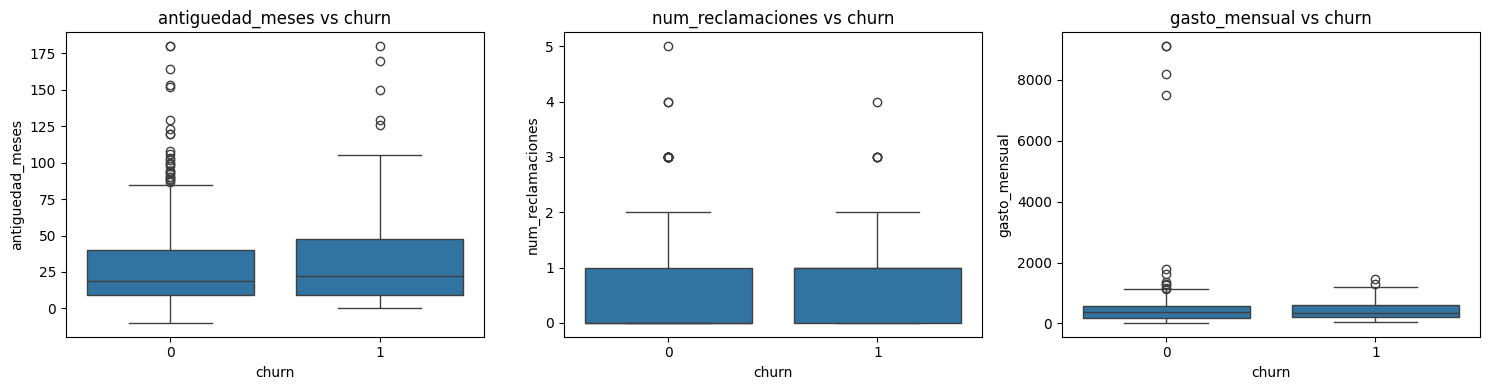

In [ ]:
# Numérica vs target categórico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["antiguedad_meses", "num_reclamaciones", "gasto_mensual"]):
    sns.boxplot(data=clientes_df, x="churn", y=col, ax=ax)
    ax.set_title(f"{col} vs churn")

plt.tight_layout()
plt.show()

In [ ]:
# Categórica vs target categórico
pd.crosstab(clientes_df["segmento"], clientes_df["churn"], normalize="index").round(3)

churn,0,1
segmento,,
basic,0.789,0.211
plus,0.818,0.182
premium,0.894,0.106


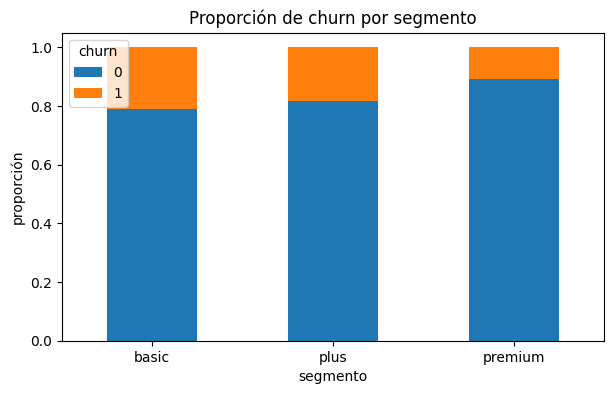

In [ ]:
ct = pd.crosstab(clientes_df["segmento"], clientes_df["churn"], normalize="index")
ct.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("Proporción de churn por segmento")
plt.ylabel("proporción")
plt.xticks(rotation=0)
plt.show()

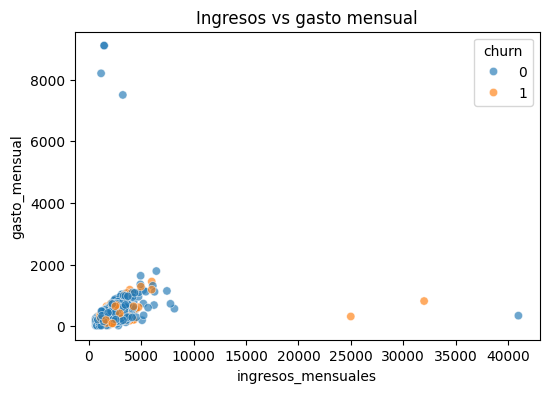

In [ ]:
# Numérica vs numérica
plt.figure(figsize=(6, 4))
sns.scatterplot(data=clientes_df, x="ingresos_mensuales", y="gasto_mensual", hue="churn", alpha=0.65)
plt.title("Ingresos vs gasto mensual")
plt.show()

## Medidas estadísticas útiles

- Numérica-numérica: correlación de Pearson/Spearman.
- Categórica-categórica: chi-cuadrado, proporciones, V de Cramér.
- Numérica-categórica: comparación de distribuciones, ANOVA, Kruskal-Wallis.
- Feature-target: mutual information, importancias de modelos, análisis de negocio.

No hace falta aplicar tests estadísticos por aplicar. Cada test tiene supuestos y contexto.

In [ ]:
# Ejemplo: chi-cuadrado entre segmento y churn
from scipy.stats import chi2_contingency

contingency = pd.crosstab(clientes_df["segmento"], clientes_df["churn"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("chi2:", round(chi2, 3))
print("p-value:", round(p, 5))
print("grados de libertad:", dof)
contingency

chi2: 5.422
p-value: 0.06648
grados de libertad: 2


churn,0,1
segmento,,
basic,276,74
plus,166,37
premium,84,10


<a id="del_features"></a>
[Volver al índice](#init)

# 9. Eliminación de features

Eliminar variables puede ser razonable si:

- son identificadores sin valor predictivo generalizable,
- tienen demasiados missings,
- son constantes,
- son duplicadas,
- generan fuga de información,
- son demasiado caras o imposibles de conseguir en producción,
- complican el modelo sin aportar valor.

Pero eliminar por automatismo puede ser peligroso. Una variable con muchos missings puede ser muy informativa si el missing tiene significado.

In [ ]:
# Ejemplo: columnas candidatas a eliminar por reglas simples
feature_audit = preliminary_feature_audit(clientes_df, target="churn")
feature_audit[feature_audit["drop_candidate"]]

,dtype,n_missing,pct_missing,n_unique,pct_unique,examples,drop_candidate,reason
ingresos_mensuales,float64,39,5.930,606,92.100,"[2676.24, 4500.38, 1994.71, 3819.7]",True,alta cardinalidad > 90%
gasto_mensual,float64,22,3.340,619,94.070,"[194.23, 554.08, 311.52, 696.43]",True,alta cardinalidad > 90%
id_cliente,str,0,0.000,650,98.780,"[C00592, C00310, C00291, C00063]",True,alta cardinalidad > 90%


In [ ]:
# Ejemplo práctico: id_cliente no lo usaremos como feature.
X_without_id = clientes_clean.drop(columns=["churn", "id_cliente"])
y_clean = clientes_clean["churn"]

print("Columnas originales sin target:", clientes_clean.drop(columns="churn").shape[1])
print("Columnas tras quitar id_cliente:", X_without_id.shape[1])

Columnas originales sin target: 11
Columnas tras quitar id_cliente: 10


<a id="duplicados"></a>
[Volver al índice](#init)

# 10. Duplicados

Los duplicados pueden aparecer por:

- errores al exportar,
- joins mal hechos,
- registros repetidos,
- usuarios con varias operaciones legítimas,
- granularidad mal entendida.

No siempre hay que eliminar duplicados. Primero hay que entender qué representa cada fila.

In [ ]:
print("Duplicados exactos:", clientes_df.duplicated().sum())
print("IDs duplicados:", clientes_df["id_cliente"].duplicated().sum())

clientes_df[clientes_df.duplicated(keep=False)].sort_values("id_cliente").head(10)

Duplicados exactos: 8
IDs duplicados: 8


,id_cliente,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,churn
8,C00072,31,19,"1,456.940","9,100.000",0,5,NaN,basic,Sevilla,sí,0
102,C00072,31,19,"1,456.940","9,100.000",0,5,NaN,basic,Sevilla,sí,0
67,C00131,25,59,"1,916.500",507.850,0,1,web,premium,Madrid,sí,0
273,C00131,25,59,"1,916.500",507.850,0,1,web,premium,Madrid,sí,0
69,C00181,45,10,"3,030.860",194.260,1,9,tienda,basic,Valencia,no,0
116,C00181,45,10,"3,030.860",194.260,1,9,tienda,basic,Valencia,no,0
51,C00220,39,10,"1,029.580",20.000,0,4,web,premium,Alicante,sí,0
597,C00220,39,10,"1,029.580",20.000,0,4,web,premium,Alicante,sí,0
57,C00326,23,92,"2,945.370",567.340,0,3,tienda,plus,Valencia,sí,1
183,C00326,23,92,"2,945.370",567.340,0,3,tienda,plus,Valencia,sí,1


In [ ]:
clientes_no_duplicates = clientes_df.drop_duplicates().copy()
print("Antes:", clientes_df.shape)
print("Después de drop_duplicates:", clientes_no_duplicates.shape)

Antes: (658, 12)
Después de drop_duplicates: (650, 12)


## Duplicados por subconjunto de columnas

A veces no buscamos filas idénticas, sino duplicados según claves de negocio.

Ejemplo: si `id_cliente` debería ser único, entonces varios registros con el mismo `id_cliente` pueden ser sospechosos.

In [ ]:
clientes_df[clientes_df.duplicated(subset=["id_cliente"], keep=False)].sort_values("id_cliente").head(12)

,id_cliente,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,churn
8,C00072,31,19,"1,456.940","9,100.000",0,5,NaN,basic,Sevilla,sí,0
102,C00072,31,19,"1,456.940","9,100.000",0,5,NaN,basic,Sevilla,sí,0
67,C00131,25,59,"1,916.500",507.850,0,1,web,premium,Madrid,sí,0
273,C00131,25,59,"1,916.500",507.850,0,1,web,premium,Madrid,sí,0
69,C00181,45,10,"3,030.860",194.260,1,9,tienda,basic,Valencia,no,0
116,C00181,45,10,"3,030.860",194.260,1,9,tienda,basic,Valencia,no,0
51,C00220,39,10,"1,029.580",20.000,0,4,web,premium,Alicante,sí,0
597,C00220,39,10,"1,029.580",20.000,0,4,web,premium,Alicante,sí,0
57,C00326,23,92,"2,945.370",567.340,0,3,tienda,plus,Valencia,sí,1
183,C00326,23,92,"2,945.370",567.340,0,3,tienda,plus,Valencia,sí,1


<a id="missings"></a>
[Volver al índice](#init)

# 11. Missings

Los missings pueden aparecer por muchos motivos:

- dato no preguntado,
- dato no aplicable,
- error de integración,
- usuario no responde,
- sensores fallan,
- distintas fuentes tienen distinto esquema.

Decisiones habituales:

| Estrategia | Cuándo puede tener sentido |
|---|---|
| Eliminar filas | pocos missings y muchos datos |
| Eliminar columnas | demasiados missings y poco valor |
| Imputar media/mediana | numéricas, baseline rápido |
| Imputar moda | categóricas |
| Crear indicador de missing | si el missing puede ser informativo |
| Modelos que aceptan missing | algunos árboles modernos |

La imputación debe aprenderse en train y aplicarse a test. Otra vez: `Pipeline`.

In [ ]:
missing_summary = (
    clientes_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("pct_missing")
)
missing_summary[missing_summary["pct_missing"] > 0]

,pct_missing
ingresos_mensuales,5.927
gasto_mensual,3.343
canal_entrada,2.584
segmento,1.672


<Figure size 800x400 with 0 Axes>

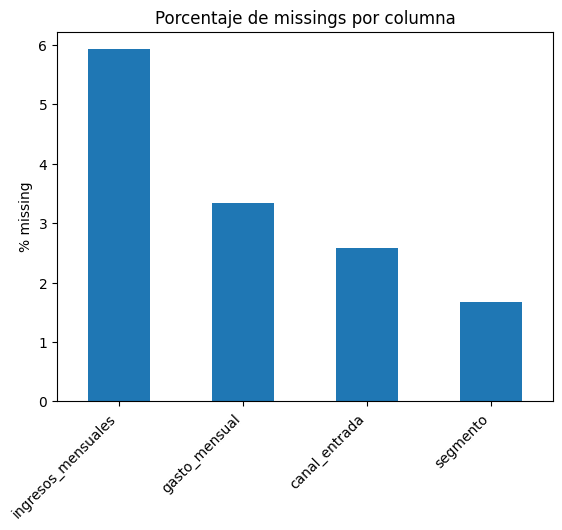

In [ ]:
plt.figure(figsize=(8, 4))
missing_summary[missing_summary["pct_missing"] > 0].plot(kind="bar", legend=False)
plt.ylabel("% missing")
plt.title("Porcentaje de missings por columna")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
# Ejemplo manual: imputación sencilla sobre una copia
example_imputed = clientes_df.copy()
example_imputed["ingresos_mensuales"] = example_imputed["ingresos_mensuales"].fillna(example_imputed["ingresos_mensuales"].median())
example_imputed["canal_entrada"] = example_imputed["canal_entrada"].fillna(example_imputed["canal_entrada"].mode()[0])

example_imputed[["ingresos_mensuales", "canal_entrada"]].isna().sum()

ingresos_mensuales    0
canal_entrada         0
dtype: int64

La celda anterior sirve para entender la operación, pero en un modelo real preferiremos hacerlo dentro del pipeline.

In [ ]:
# Imputación dentro de pipelines separados para numéricas y categóricas
from sklearn.compose import make_column_selector

numeric_pipe_with_scaling = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe_with_ohe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocess_for_model = ColumnTransformer([
    ("num", numeric_pipe_with_scaling, make_column_selector(dtype_include=np.number)),
    ("cat", categorical_pipe_with_ohe, make_column_selector(dtype_exclude=np.number)),
])

preprocess_for_model

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

<a id="errores"></a>
[Volver al índice](#init)

# 12. Anomalías y errores

No todo valor raro es un outlier estadístico. Algunos son errores de negocio.

Ejemplos:

- edad negativa,
- edad de 130 años si no tiene sentido en el dominio,
- antigüedad negativa,
- categorías imposibles,
- fechas futuras,
- importes negativos donde no debería haberlos.

Estos casos suelen tratarse antes del modelado.

In [ ]:
# Reglas de negocio sencillas para detectar errores
mask_errors = (
    ~clientes_df["edad"].between(18, 90)
    | (clientes_df["antiguedad_meses"] < 0)
    | ~clientes_df["canal_entrada"].isin(["web", "tienda", "call_center", np.nan])
    | ~clientes_df["usa_app"].isin(["sí", "no", np.nan])
)

clientes_df.loc[mask_errors, ["id_cliente", "edad", "antiguedad_meses", "canal_entrada", "usa_app", "churn"]]

,id_cliente,edad,antiguedad_meses,canal_entrada,usa_app,churn
117,C00433,130,57,web,sí,0
187,C00177,44,34,tienda,quizá,1
336,C00407,52,15,desconocido??,no,0
514,C00585,66,-10,tienda,sí,0
655,C00270,-4,22,call_center,no,0


In [ ]:
clientes_clean = basic_error_cleaning(clientes_df)
print("Errores antes:", mask_errors.sum())
print("Missings después de convertir errores a NaN:")
clientes_clean[["edad", "antiguedad_meses", "canal_entrada", "usa_app"]].isna().sum()

Errores antes: 5
Missings después de convertir errores a NaN:


edad                 2
antiguedad_meses     1
canal_entrada       17
usa_app              1
dtype: int64

<a id="outliers"></a>
[Volver al índice](#init)

# 13. Outliers

Un outlier es un valor muy alejado del comportamiento habitual.

Puede ser:

- un error,
- un caso real extremo,
- un cliente muy valioso,
- un fraude,
- un evento raro que precisamente queremos detectar.

Por eso no existe una única respuesta. Hay que decidir con criterio.

## Métodos habituales

- Regla IQR.
- Z-score.
- Boxplot.
- Percentiles/winsorización.
- Modelos de anomalías: Isolation Forest, Local Outlier Factor, etc.

In [ ]:
def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

col = "ingresos_mensuales"
low, high = iqr_bounds(clientes_df[col].dropna())
outlier_mask = (clientes_df[col] < low) | (clientes_df[col] > high)

print("Límite inferior:", round(low, 2))
print("Límite superior:", round(high, 2))
print("Outliers detectados:", outlier_mask.sum())

clientes_df.loc[outlier_mask, ["id_cliente", col, "churn"]].sort_values(col, ascending=False).head(10)

Límite inferior: -382.34
Límite superior: 4763.92
Outliers detectados: 21


,id_cliente,ingresos_mensuales,churn
166,C00523,"41,000.000",0
11,C00135,"32,000.000",1
372,C00635,"25,000.000",1
15,C00299,"8,165.090",0
70,C00452,"7,789.400",0
631,C00021,"7,450.590",0
640,C00343,"6,440.370",0
481,C00129,"6,265.500",0
225,C00028,"6,220.730",0
418,C00440,"6,103.710",0


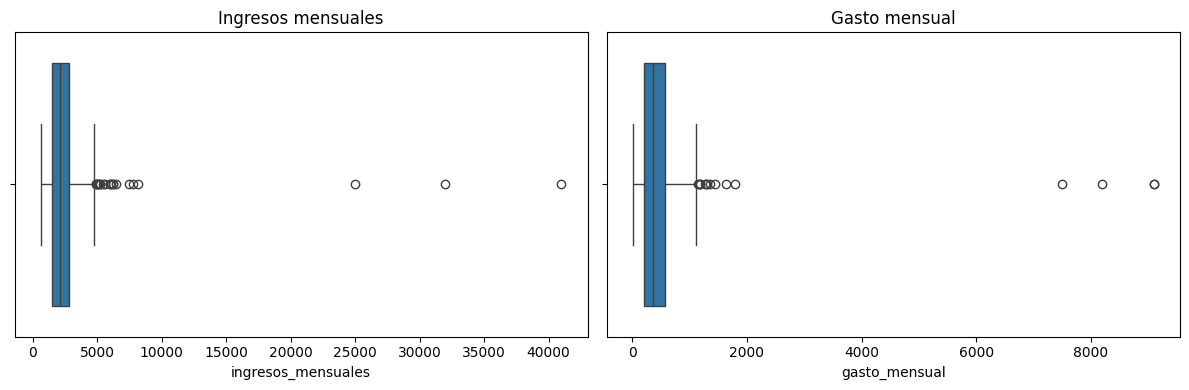

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=clientes_df, x="ingresos_mensuales", ax=axes[0])
axes[0].set_title("Ingresos mensuales")
sns.boxplot(data=clientes_df, x="gasto_mensual", ax=axes[1])
axes[1].set_title("Gasto mensual")
plt.tight_layout()
plt.show()

## Winsorización / clipping

Una alternativa a eliminar outliers es limitar valores extremos a ciertos percentiles. Debe aprenderse con train y aplicarse a test.

Aquí lo mostramos manualmente para entender la idea.

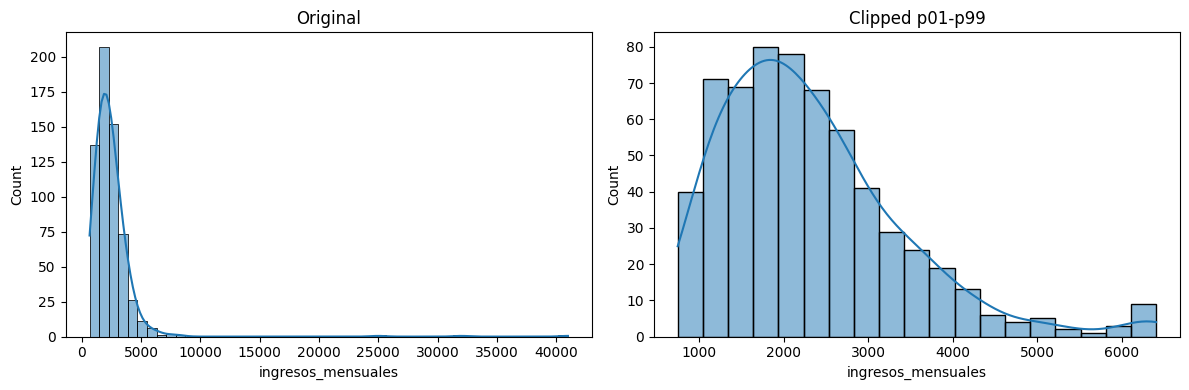

In [ ]:
col = "ingresos_mensuales"
p01, p99 = clientes_df[col].quantile([0.01, 0.99])

clientes_clipped = clientes_df.copy()
clientes_clipped[col] = clientes_clipped[col].clip(lower=p01, upper=p99)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clientes_df[col], kde=True, ax=axes[0], color="C0")
axes[0].set_title("Original")
sns.histplot(clientes_clipped[col], kde=True, ax=axes[1], color="C0")
axes[1].set_title("Clipped p01-p99")
plt.tight_layout()
plt.show()

<a id="feat_engi"></a>
[Volver al índice](#init)

# 14. Feature Engineering

Feature Engineering es transformar los datos para que el modelo pueda aprender mejor.

Incluye:

1. Transformaciones numéricas.
2. Encodings de categóricas.
3. Creación de nuevas variables.
4. Escalados.
5. Tratamiento de fechas/texto si existieran.

La clave es que estas transformaciones deben ser reproducibles y aplicarse igual a train, validation, test y producción.

## 14.1 Transformaciones numéricas

Transformaciones habituales:

- `log1p(x)`: útil para variables positivas y asimétricas.
- `PowerTransformer`: Yeo-Johnson o Box-Cox.
- binning: convertir numérica en grupos.
- ratios: una variable dividida por otra.

No todas las transformaciones mejoran todos los modelos. Por ejemplo, árboles suelen necesitar menos escalado que modelos lineales, kNN, SVM o redes neuronales.

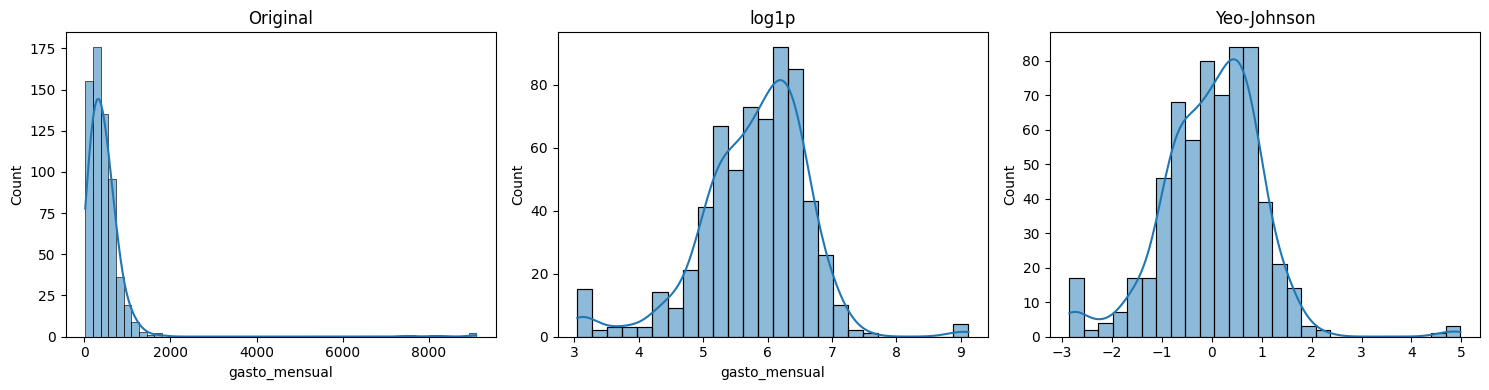

In [ ]:
from sklearn.preprocessing import PowerTransformer

col = "gasto_mensual"
series = clientes_df[col].dropna()

pt = PowerTransformer(method="yeo-johnson")
yj = np.asarray(pt.fit_transform(series.to_frame())).ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(series, kde=True, ax=axes[0], color="C0")
axes[0].set_title("Original")
sns.histplot(np.log1p(series), kde=True, ax=axes[1], color="C0")
axes[1].set_title("log1p")
sns.histplot(yj, kde=True, ax=axes[2], color="C0")
axes[2].set_title("Yeo-Johnson")
plt.tight_layout()
plt.show()

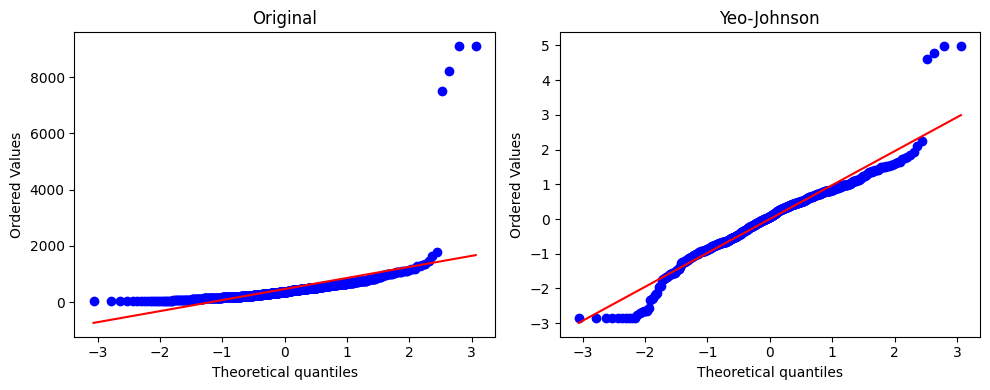

In [ ]:
# Q-Q plot antes/después para entender visualmente la normalidad aproximada
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(series, dist="norm", plot=axes[0])
axes[0].set_title("Original")
stats.probplot(yj, dist="norm", plot=axes[1])
axes[1].set_title("Yeo-Johnson")
plt.tight_layout()
plt.show()

## 14.2 Encodings

Los modelos de `scikit-learn` normalmente necesitan números.

Opciones frecuentes:

| Técnica | Cuándo usarla |
|---|---|
| One-hot encoding | categóricas nominales de baja/media cardinalidad |
| Ordinal encoding | categorías con orden real |
| Target encoding | con cuidado, requiere validación correcta |
| Hashing | alta cardinalidad, especialmente texto/categorías grandes |

En clase, `OneHotEncoder(handle_unknown="ignore")` es una opción segura para empezar.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

small_cat = clientes_clean[["segmento", "canal_entrada", "usa_app"]].head(8).copy()
small_cat

,segmento,canal_entrada,usa_app
0,basic,tienda,sí
1,basic,call_center,sí
2,basic,call_center,sí
3,basic,tienda,sí
4,plus,web,no
5,basic,web,sí
6,plus,web,sí
7,basic,web,sí


In [ ]:
# One-hot encoding actual, robusto ante categorías nuevas
encoder = make_one_hot_encoder()
encoded = encoder.fit_transform(small_cat.fillna("missing"))

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(small_cat.columns),
    index=small_cat.index,
)
encoded_df.head()

,segmento_basic,segmento_plus,canal_entrada_call_center,canal_entrada_tienda,canal_entrada_web,usa_app_no,usa_app_sí
0,1.000,0.000,0.000,1.000,0.000,0.000,1.000
1,1.000,0.000,1.000,0.000,0.000,0.000,1.000
2,1.000,0.000,1.000,0.000,0.000,0.000,1.000
3,1.000,0.000,0.000,1.000,0.000,0.000,1.000
4,0.000,1.000,0.000,0.000,1.000,1.000,0.000


In [ ]:
# Encoding ordinal cuando existe orden semántico.
segment_order = [["basic", "plus", "premium"]]
ord_enc = OrdinalEncoder(categories=segment_order, handle_unknown="use_encoded_value", unknown_value=-1)

segment_encoded = ord_enc.fit_transform(clientes_clean[["segmento"]].fillna("basic"))
pd.DataFrame({"segmento": clientes_clean["segmento"].head(10), "segmento_ordinal": np.asarray(segment_encoded[:10]).ravel()})

,segmento,segmento_ordinal
0,basic,0.000
1,basic,0.000
2,basic,0.000
3,basic,0.000
4,plus,1.000
5,basic,0.000
6,plus,1.000
7,basic,0.000
8,basic,0.000
9,basic,0.000


## 14.3 Nuevas features

Crear variables suele aportar más que cambiar de modelo.

Ejemplos:

- ratios: `gasto / ingresos`,
- flags: `tiene_reclamaciones`,
- grupos: antigüedad baja/media/alta,
- interacciones: gasto alto y poca antigüedad.

In [ ]:
clientes_features = clientes_clean.copy()
clientes_features["ratio_gasto_ingresos"] = clientes_features["gasto_mensual"] / clientes_features["ingresos_mensuales"]
clientes_features["tiene_reclamaciones"] = (clientes_features["num_reclamaciones"] > 0).astype(int)
clientes_features["antiguedad_grupo"] = pd.cut(
    clientes_features["antiguedad_meses"],
    bins=[-1, 6, 24, 60, np.inf],
    labels=["nueva", "reciente", "estable", "veterana"],
)

clientes_features[["gasto_mensual", "ingresos_mensuales", "ratio_gasto_ingresos", "tiene_reclamaciones", "antiguedad_grupo"]].head()

,gasto_mensual,ingresos_mensuales,ratio_gasto_ingresos,tiene_reclamaciones,antiguedad_grupo
0,194.230,"2,676.240",0.073,1,estable
1,554.080,"4,500.380",0.123,0,nueva
2,311.520,"1,994.710",0.156,1,estable
3,696.430,"3,819.700",0.182,1,nueva
4,231.610,"2,201.980",0.105,0,nueva


## 14.4 Escalados

Algunos modelos son sensibles a la escala:

- regresión logística,
- regresión lineal regularizada,
- SVM,
- kNN,
- redes neuronales,
- PCA.

Otros, como árboles y random forest, suelen ser menos sensibles.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

scaling_demo = clientes_clean[["edad", "ingresos_mensuales", "gasto_mensual"]].dropna().head(8)

std_scaled = pd.DataFrame(
    StandardScaler().fit_transform(scaling_demo),
    columns=[f"std_{c}" for c in scaling_demo.columns],
    index=scaling_demo.index,
)

minmax_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(scaling_demo),
    columns=[f"minmax_{c}" for c in scaling_demo.columns],
    index=scaling_demo.index,
)

pd.concat([scaling_demo, std_scaled, minmax_scaled], axis=1)

,edad,ingresos_mensuales,gasto_mensual,std_edad,std_ingresos_mensuales,std_gasto_mensual,minmax_edad,minmax_ingresos_mensuales,minmax_gasto_mensual
0,64.000,"2,676.240",194.230,NaN,NaN,NaN,NaN,NaN,NaN
1,56.000,"4,500.380",554.080,NaN,NaN,NaN,NaN,NaN,NaN
2,44.000,"1,994.710",311.520,NaN,NaN,NaN,NaN,NaN,NaN
3,49.000,"3,819.700",696.430,NaN,NaN,NaN,NaN,NaN,NaN
4,46.000,"2,201.980",231.610,NaN,NaN,NaN,NaN,NaN,NaN
6,40.000,"1,947.520",438.590,NaN,NaN,NaN,NaN,NaN,NaN
8,31.000,"1,456.940","9,100.000",NaN,NaN,NaN,NaN,NaN,NaN
9,45.000,"1,447.500",443.430,NaN,NaN,NaN,NaN,NaN,NaN


<a id="feat_reduc"></a>
[Volver al índice](#init)

# 15. Feature Reduction

Reducir features puede ayudar a:

- simplificar el modelo,
- mejorar interpretabilidad,
- reducir ruido,
- reducir coste computacional,
- evitar overfitting.

Técnicas habituales:

- selección por reglas de negocio,
- correlación y colinealidad,
- importancias de modelo,
- `SelectKBest`,
- regularización L1,
- PCA.

PCA no selecciona columnas originales: crea nuevas componentes.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X_kbest = clientes_features.drop(columns=["churn", "id_cliente"])
y_kbest = clientes_features["churn"]

# Para SelectKBest necesitamos una matriz numérica. Usamos un preprocesado simple.
preprocess_kbest = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), make_column_selector(dtype_include=np.number)),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]), make_column_selector(dtype_exclude=np.number)),
])

X_kbest_num = preprocess_kbest.fit_transform(X_kbest)
feature_names_kbest = preprocess_kbest.get_feature_names_out()

selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_kbest_num, y_kbest)

kbest_df = (
    pd.DataFrame({"feature": feature_names_kbest, "score": selector.scores_})
    .sort_values("score", ascending=False)
    .head(10)
)
kbest_df

,feature,score
14,cat__provincia_Alicante,0.034
16,cat__provincia_Bilbao,0.019
11,cat__segmento_basic,0.016
3,num__gasto_mensual,0.014
17,cat__provincia_Madrid,0.011
6,num__ratio_gasto_ingresos,0.009
27,cat__antiguedad_grupo_veterana,0.009
7,num__tiene_reclamaciones,0.008
24,cat__antiguedad_grupo_estable,0.003
10,cat__canal_entrada_web,0.002


In [ ]:
from sklearn.decomposition import PCA

num_cols_pca = ["edad", "antiguedad_meses", "ingresos_mensuales", "gasto_mensual", "num_reclamaciones", "visitas_web_mes"]
X_pca = clientes_clean[num_cols_pca]

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
])

pca_pipe.fit(X_pca)
pca = pca_pipe.named_steps["pca"]

explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
})
explained

,component,explained_variance_ratio,cumulative
0,PC1,0.192,0.192
1,PC2,0.187,0.379
2,PC3,0.167,0.546
3,PC4,0.163,0.709
4,PC5,0.147,0.856
5,PC6,0.144,1.000


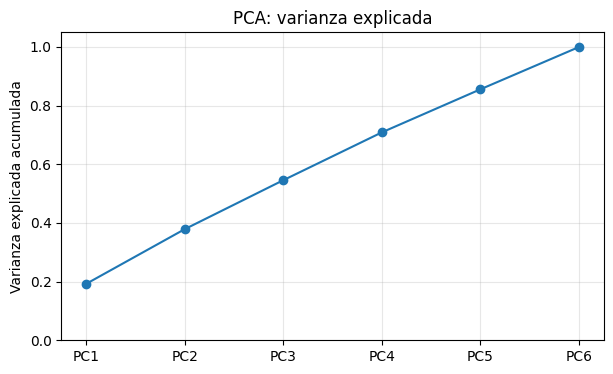

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(explained["component"], explained["cumulative"], marker="o")
plt.ylim(0, 1.05)
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA: varianza explicada")
plt.grid(True, alpha=0.3)
plt.show()

<a id="choose_metric"></a>
[Volver al índice](#init)

# 16. Escoger métrica del modelo

La métrica no se elige al final. Se elige al principio, en función del problema.

## Clasificación

| Métrica | Cuándo puede importar |
|---|---|
| Accuracy | clases balanceadas y errores similares |
| Balanced accuracy | clases desbalanceadas |
| Precision | falsos positivos caros |
| Recall | falsos negativos caros |
| F1 | equilibrio precision/recall |
| ROC AUC | ranking global de probabilidades |
| PR AUC | muy útil con clase positiva rara |

## Regresión

| Métrica | Interpretación |
|---|---|
| MAE | error absoluto medio, robusto e interpretable |
| MSE | penaliza mucho errores grandes |
| RMSE | raíz del MSE, en unidades del target |
| R² | proporción de varianza explicada |
| MAPE | error porcentual, problemático con ceros |

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Dataset limpio con features creadas para modelar
model_df = clientes_features.drop_duplicates().copy()
X_model = model_df.drop(columns=["churn", "id_cliente"])
y_model = model_df["churn"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

clf_pipe = Pipeline([
    ("preprocess", preprocess_for_model),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

clf_pipe.fit(X_train_m, y_train_m)
y_pred = clf_pipe.predict(X_test_m)
y_proba = clf_pipe.predict_proba(X_test_m)[:, 1]

metrics_clf = pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test_m, y_pred),
        balanced_accuracy_score(y_test_m, y_pred),
        precision_score(y_test_m, y_pred),
        recall_score(y_test_m, y_pred),
        f1_score(y_test_m, y_pred),
        roc_auc_score(y_test_m, y_proba),
    ]
})
metrics_clf

,metric,value
0,accuracy,0.554
1,balanced_accuracy,0.549
2,precision,0.217
3,recall,0.542
4,f1,0.310
5,roc_auc,0.540


In [ ]:
print(classification_report(y_test_m, y_pred, target_names=["no churn", "churn"]))

              precision    recall  f1-score   support

    no churn       0.84      0.56      0.67       106
       churn       0.22      0.54      0.31        24

    accuracy                           0.55       130
   macro avg       0.53      0.55      0.49       130
weighted avg       0.73      0.55      0.60       130



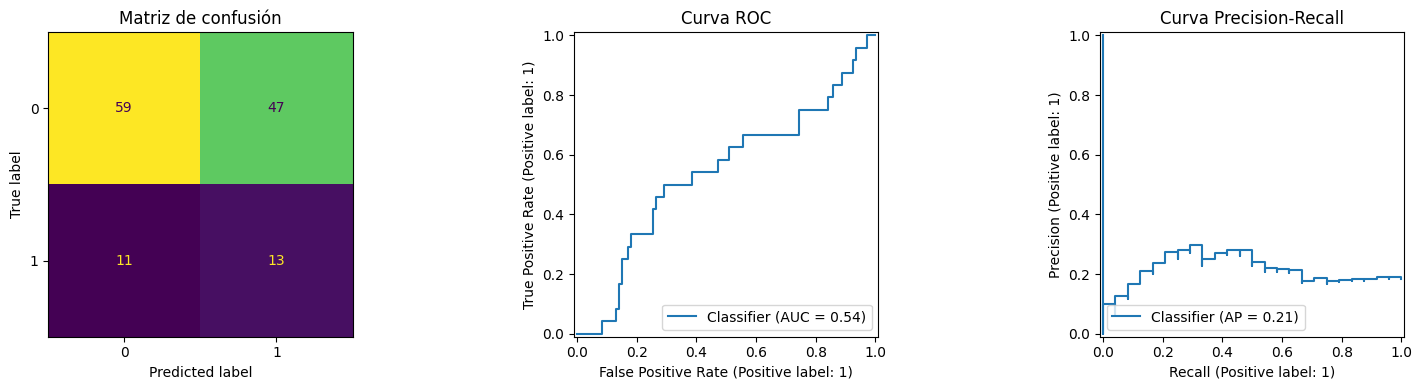

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(y_test_m, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión")
RocCurveDisplay.from_predictions(y_test_m, y_proba, ax=axes[1])
axes[1].set_title("Curva ROC")
PrecisionRecallDisplay.from_predictions(y_test_m, y_proba, ax=axes[2])
axes[2].set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred) ** 0.5

X_reg = diabetes_df.drop(columns="target")
y_reg = diabetes_df["target"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

reg_pipe.fit(X_train_r, y_train_r)
y_pred_r = reg_pipe.predict(X_test_r)

metrics_reg = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_test_r, y_pred_r),
        mean_squared_error(y_test_r, y_pred_r),
        root_mean_squared_error(y_test_r, y_pred_r),
        r2_score(y_test_r, y_pred_r),
    ]
})
metrics_reg

,metric,value
0,MAE,42.812
1,MSE,"2,892.015"
2,RMSE,53.777
3,R2,0.454


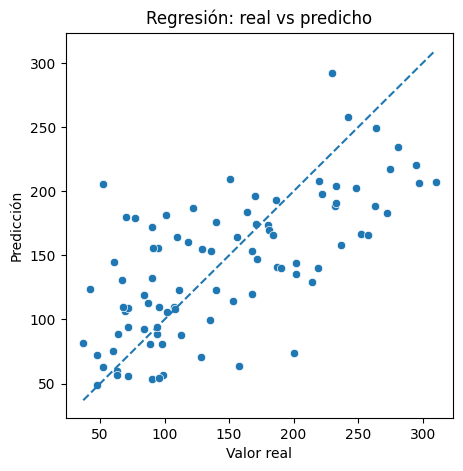

In [ ]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test_r, y=y_pred_r, color="C0")
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión: real vs predicho")
plt.show()

<a id="choose_models"></a>
[Volver al índice](#init)

# 17. Decidir qué modelos

La elección de modelos depende de varias tensiones:

| Criterio | Ejemplos |
|---|---|
| Interpretabilidad | lineales, árboles pequeños |
| Rendimiento | ensembles, boosting, modelos complejos |
| Velocidad | modelos lineales, árboles moderados |
| Tamaño de datos | algunos modelos escalan mejor que otros |
| Tipo de relación | lineal, no lineal, interacciones |
| Producción | latencia, memoria, mantenimiento |

Una estrategia razonable:

1. Baseline muy simple.
2. Modelo interpretable.
3. Modelo no lineal potente.
4. Comparación con validación cruzada.
5. Ajuste de hiperparámetros solo en candidatos prometedores.

In [ ]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

candidate_classifiers = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "knn": KNeighborsClassifier(n_neighbors=7),
}

list(candidate_classifiers.keys())

['dummy_most_frequent',
 'logistic_regression',
 'decision_tree',
 'random_forest',
 'knn']

<a id="hyperparameters"></a>
[Volver al índice](#init)

# 18. Elegir hiperparámetros

Los hiperparámetros son decisiones que no se aprenden directamente durante el entrenamiento:

- `max_depth` de un árbol,
- `n_estimators` de un random forest,
- `C` de una regresión logística o SVM,
- `n_neighbors` de kNN,
- `alpha` de Ridge/Lasso.

## Grid Search vs Random Search

| Método | Idea |
|---|---|
| GridSearchCV | prueba todas las combinaciones definidas |
| RandomizedSearchCV | prueba combinaciones aleatorias |

Importante: el ajuste de hiperparámetros debe hacerse con validación cruzada dentro de train. Test se reserva para el final.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

base_pipe = Pipeline([
    ("preprocess", preprocess_for_model),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
)

grid.fit(X_train_m, y_train_m)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 CV:", round(grid.best_score_, 3))

Mejores hiperparámetros: {'model__C': 0.1, 'model__penalty': 'l2'}
Mejor F1 CV: 0.319


In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results[["param_model__C", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

,param_model__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.100,0.437,0.319,0.016,1
1,1.000,0.436,0.306,0.034,2
2,10.000,0.441,0.286,0.046,3


<a id="pipelines"></a>
[Volver al índice](#init)

# 19. Pipelines y comparación de modelos

`Pipeline` es una de las herramientas más importantes de `scikit-learn` para proyectos reproducibles.

Ventajas:

- reduce errores,
- evita data leakage,
- permite validar correctamente,
- junta preprocesado y modelo,
- simplifica el guardado final,
- facilita GridSearchCV.

Aquí compararemos varios modelos con el mismo preprocesado.

In [ ]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

comparison_rows = []
fitted_models = {}

for name, estimator in candidate_classifiers.items():
    pipe = Pipeline([
        ("preprocess", preprocess_for_model),
        ("model", estimator),
    ])
    scores = cross_validate(
        pipe,
        X_train_m,
        y_train_m,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("f1_mean", ascending=False)
comparison_df

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,logistic_regression,0.644,0.024,0.559,0.027,0.241,0.024,0.424,0.069,0.306,0.034,0.575,0.052
2,decision_tree,0.515,0.142,0.485,0.052,0.175,0.049,0.436,0.220,0.240,0.070,0.507,0.051
4,knn,0.796,0.012,0.509,0.009,0.194,0.142,0.051,0.039,0.080,0.058,0.515,0.007
3,random_forest,0.812,0.005,0.503,0.004,0.111,0.157,0.010,0.014,0.019,0.026,0.571,0.054
0,dummy_most_frequent,0.813,0.002,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000


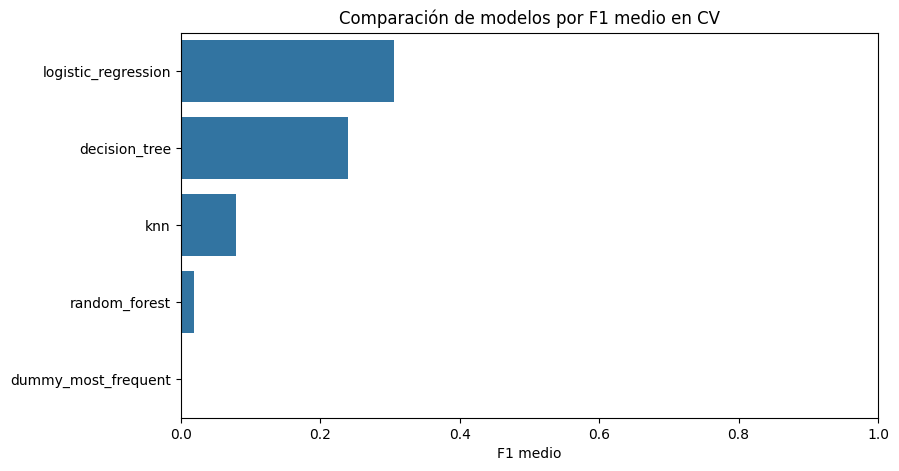

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, y="model", x="f1_mean", color="C0")
plt.xlim(0, 1)
plt.title("Comparación de modelos por F1 medio en CV")
plt.xlabel("F1 medio")
plt.ylabel("")
plt.show()

In [ ]:
# Entrenamos el mejor candidato según F1 medio de CV en TODO train.
best_model_name = comparison_df.iloc[0]["model"]
best_estimator = candidate_classifiers[best_model_name]

best_pipe = Pipeline([
    ("preprocess", preprocess_for_model),
    ("model", best_estimator),
])

best_pipe.fit(X_train_m, y_train_m)

print("Mejor modelo según CV:", best_model_name)

Mejor modelo según CV: logistic_regression


<a id="results"></a>
[Volver al índice](#init)

# 20. Resultados

Ahora sí: evaluamos una vez sobre test.

Este momento debe ser lo más aburrido posible. Si hemos usado test para tomar decisiones anteriores, el resultado ya no es una estimación honesta.

## Qué mirar

- Métrica principal.
- Métricas secundarias.
- Matriz de confusión.
- Errores concretos.
- Casos donde el modelo duda.
- Comparación contra baseline.
- Coste de falsos positivos y falsos negativos.
- Si hay overfitting: diferencia entre train/CV/test.

In [ ]:
y_pred_best = best_pipe.predict(X_test_m)

if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    y_score_best = best_pipe.predict_proba(X_test_m)[:, 1]
elif hasattr(best_pipe.named_steps["model"], "decision_function"):
    y_score_best = best_pipe.decision_function(X_test_m)
else:
    y_score_best = None

final_metrics = {
    "accuracy": accuracy_score(y_test_m, y_pred_best),
    "balanced_accuracy": balanced_accuracy_score(y_test_m, y_pred_best),
    "precision": precision_score(y_test_m, y_pred_best),
    "recall": recall_score(y_test_m, y_pred_best),
    "f1": f1_score(y_test_m, y_pred_best),
}

if y_score_best is not None:
    final_metrics["roc_auc"] = roc_auc_score(y_test_m, y_score_best)

pd.DataFrame(final_metrics, index=[best_model_name]).T.rename(columns={best_model_name: "test_score"})

,test_score
accuracy,0.554
balanced_accuracy,0.549
precision,0.217
recall,0.542
f1,0.310
roc_auc,0.540


              precision    recall  f1-score   support

    no churn       0.84      0.56      0.67       106
       churn       0.22      0.54      0.31        24

    accuracy                           0.55       130
   macro avg       0.53      0.55      0.49       130
weighted avg       0.73      0.55      0.60       130



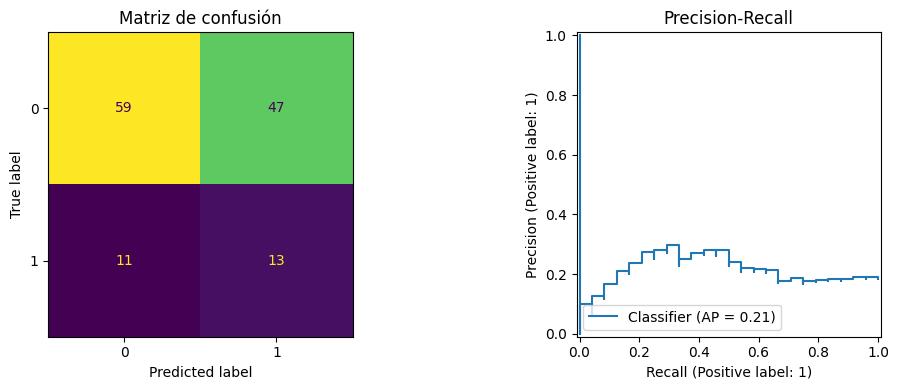

In [ ]:
print(classification_report(y_test_m, y_pred_best, target_names=["no churn", "churn"]))

fig, axes = plt.subplots(1, 2 if y_score_best is not None else 1, figsize=(11, 4))
if y_score_best is not None:
    ConfusionMatrixDisplay.from_predictions(y_test_m, y_pred_best, ax=axes[0], colorbar=False)
    axes[0].set_title("Matriz de confusión")
    PrecisionRecallDisplay.from_predictions(y_test_m, y_score_best, ax=axes[1])
    axes[1].set_title("Precision-Recall")
else:
    ConfusionMatrixDisplay.from_predictions(y_test_m, y_pred_best, ax=axes, colorbar=False)
    axes.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

## Inspección de errores

Mirar errores concretos ayuda a detectar:

- problemas de datos,
- patrones no capturados,
- clases difíciles,
- umbrales mal elegidos,
- casos que quizá necesitan reglas de negocio.

In [ ]:
errors = X_test_m.copy()
errors["y_true"] = y_test_m.values
errors["y_pred"] = y_pred_best
if y_score_best is not None:
    errors["score_churn"] = y_score_best

errors[errors["y_true"] != errors["y_pred"]].head(10)

,edad,antiguedad_meses,ingresos_mensuales,gasto_mensual,num_reclamaciones,visitas_web_mes,canal_entrada,segmento,provincia,usa_app,ratio_gasto_ingresos,tiene_reclamaciones,antiguedad_grupo,y_true,y_pred,score_churn
66,22.000,0.000,"2,382.680",196.040,2,4,web,plus,Barcelona,sí,0.082,1,nueva,0,1,0.656
385,22.000,9.000,993.050,212.390,1,3,call_center,plus,Madrid,sí,0.214,1,reciente,0,1,0.550
63,34.000,4.000,"2,850.380",195.540,1,5,tienda,plus,Madrid,no,0.069,1,nueva,0,1,0.755
630,63.000,12.000,"1,077.090",307.100,0,3,tienda,basic,Valencia,sí,0.285,0,reciente,1,0,0.218
589,33.000,62.000,"1,845.320",119.730,0,5,web,plus,Sevilla,sí,0.065,0,veterana,0,1,0.533
354,36.000,18.000,"3,886.470",178.610,0,6,call_center,plus,Madrid,sí,0.046,0,reciente,1,0,0.473
606,41.000,57.000,"2,191.310",746.460,3,8,web,basic,Valencia,sí,0.341,1,estable,0,1,0.584
625,38.000,44.000,"2,488.520",583.320,1,3,web,basic,Valencia,no,0.234,1,estable,0,1,0.581
256,38.000,5.000,"2,763.280",574.090,1,2,tienda,basic,Bilbao,sí,0.208,1,nueva,0,1,0.569
637,32.000,40.000,"2,344.560",231.500,0,2,NaN,plus,Madrid,no,0.099,0,estable,0,1,0.626


## Guardar el modelo

Si el modelo final es un `Pipeline`, guardamos preprocesado y modelo juntos. Esa es la forma correcta de reproducir predicciones después.

In [ ]:
import joblib

model_path = Path("modelo_churn_pipeline.joblib")
joblib.dump(best_pipe, model_path)

print(f"Modelo guardado en: {model_path.resolve()}")

Modelo guardado en: C:\Users\Ort\Desktop\ANBAN\ML-DL-BOOTCAMP ANBAN 2026\modelo_churn_pipeline.joblib


In [ ]:
# Cargar el modelo y hacer una predicción rápida
loaded_model = joblib.load(model_path)
loaded_pred = loaded_model.predict(X_test_m.head(5))

pd.DataFrame({
    "prediccion_churn": loaded_pred,
    "real": y_test_m.head(5).values,
})

,prediccion_churn,real
0,1,0
1,1,0
2,1,0
3,0,1
4,1,0


## Checklist final del proyecto

Antes de dar por cerrado un proyecto de ML, revisa:

- [ ] ¿El target está bien definido?
- [ ] ¿Train/test se separó al principio?
- [ ] ¿Hay data leakage?
- [ ] ¿Las imputaciones, escalados y encodings están dentro de pipeline?
- [ ] ¿La métrica elegida responde al problema real?
- [ ] ¿Hay baseline?
- [ ] ¿Se compararon varios modelos?
- [ ] ¿Se usó validación cruzada en train?
- [ ] ¿Test se usó una sola vez al final?
- [ ] ¿Se inspeccionaron errores?
- [ ] ¿El modelo se puede guardar y recargar?
- [ ] ¿Sabemos cómo se usará en producción?

## Ideas para ampliar en clase

1. Cambiar la métrica principal de `f1` a `recall` y observar qué modelo gana.
2. Probar diferentes umbrales de decisión en vez de usar 0.5.
3. Añadir `RandomizedSearchCV`.
4. Comparar `OneHotEncoder` con `OrdinalEncoder` cuando tenga sentido.
5. Añadir una variable de fuga artificial y ver cómo infla la métrica.
6. Hacer una versión de regresión completa con `diabetes_df`.
7. Añadir SHAP o permutation importance para interpretabilidad.

---

Fin del notebook.